# 実行準備

## ライブラリのインストール

In [1]:
import sys
import os
import importlib

## ディレクトリ情報取得

In [2]:
current_dir = os.getcwd()
python_root = current_dir
if not os.path.isdir(os.path.join(python_root, 'source')):
    parent_dir = os.path.dirname(current_dir)
    if os.path.isdir(os.path.join(parent_dir, 'source')):
        python_root = parent_dir
    else:
        candidate = os.path.join(current_dir, 'population_job', 'python')
        if os.path.isdir(os.path.join(candidate, 'source')):
            python_root = candidate

if python_root not in sys.path:
    sys.path.insert(0, python_root)

print(f"現在のディレクトリ: {current_dir}")
print(f"python root: {python_root}")
print(f"Python実行ファイル: {sys.executable}")

現在のディレクトリ: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\notebook
python root: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python
Python実行ファイル: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\.venv\Scripts\python.exe


## 自作ライブラリのインストール

In [3]:
# 再実行時にソースを更新した場合でも反映するため、すでに読み込まれているモジュールはreloadする。
def reload_or_import(module_name):
    if module_name in sys.modules:
        return importlib.reload(sys.modules[module_name])
    return importlib.import_module(module_name)

# ConnectDB.pyからFetch_data関数をインポート
try:
    reload_or_import("source.mylib.ConnectDB")
    from source.mylib.ConnectDB import *
    print("✓ source/mylib/ConnectDB.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# MakeOutput.pyから関数をインポート
try:
    reload_or_import("source.mylib.MakeOutput")
    from source.mylib.MakeOutput import *
    print("✓ source/mylib/MakeOutput.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# ReadWriteData.pyから関数をインポート
try:
    reload_or_import("source.mylib.ReadWriteData")
    from source.mylib.ReadWriteData import *
    print("✓ source/mylib/ReadWriteData.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# Preprocessing.pyから関数をインポート
try:
    reload_or_import("source.mylib.Preprocessing")
    from source.mylib.Preprocessing import *
    print("✓ source/mylib/Preprocessing.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# OperateDataFrame.pyから関数をインポート
try:
    reload_or_import("source.mylib.OperateDataFrame")
    from source.mylib.OperateDataFrame import *
    print("✓ source/mylib/OperateDataFrame.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# Models.pyから関数をインポート
try:
    reload_or_import("source.mylib.Models")
    from source.mylib.Models import *
    print("✓ source/mylib/Models.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

✓ source/mylib/ConnectDB.py のインポートに成功しました
✓ source/mylib/MakeOutput.py のインポートに成功しました
✓ source/mylib/ReadWriteData.py のインポートに成功しました
✓ source/mylib/Preprocessing.py のインポートに成功しました
✓ source/mylib/OperateDataFrame.py のインポートに成功しました
✓ source/mylib/Models.py のインポートに成功しました


# テーブル内容取得

dataフォルダにcsvファイルが存在する場合はそれを取得、存在しない場合はSQLDBに接続して内容を取得

## configファイルのパス指定

In [4]:
# データベースへの接続文字列をconfigファイルから読み込む。
config_path = os.path.join(python_root, 'config', 'connect_DB.config')
print(f"configファイルのパス: {config_path}")

configファイルのパス: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\config\connect_DB.config


## dataフォルダのパス指定

In [5]:
data_dir = os.path.join(python_root, 'data')
print(f"dataディレクトリのパス: {data_dir}")

dataディレクトリのパス: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\data


## dataディレクトリにcsvファイルが存在するかどうかの確認

### データを一括管理するための辞書を作成

In [6]:
data_dict ={}

### データを取得
取得データは以下の通り  
- economic_census_employments：経済センサス（都道府県×業種×性別での就業者数）テーブル
- economic_census_code：経済センサス（都道府県×業種×性別での就業者数）テーブルの産業コードのコード値対応表
- laborforce_generation_industry_employ：労働力調査（全国の総就業者数）テーブル
- laborforce_generation_industry_employ_codes：労働力調査（全国の総就業者数）テーブルの産業コードのコード値対応表
- prefecture_metadata_codes：都道府県コードのコード値対応表
- sex_metadata_codes：性別コードのコード値対応表
- generation_metadata_codes：年代コードのコード値対応表
- population_curated：人口動態テーブル

In [7]:
# データ名のリスト
data_name_list = [
    'economic_census_employments', 
    'economic_census_code', 
    'laborforce_generation_industry_employ', 
    'laborforce_generation_industry_employ_codes', 
    'prefecture_metadata_codes', 
    'sex_metadata_codes', 
    'generation_metadata_codes',
    'population_curated',
    ]

# データ名のリストをループして、data_dictにデータと列名、行数を追加
for data_name in data_name_list:
    Add_data_to_dict(data_dict, data_name, data_dir, config_path)
    data_dict[f'{data_name}_columns'], data_dict[f'{data_name}_number_of_rows'] = Check_df(data_dict[f'{data_name}_df'])

✓ ファイルが存在します: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\data\economic_census_employments.csv
✓ ファイル取得完了
データフレームの冒頭5行を表示
   prefecture_code  year  industry_code  employments_total_t  \
0                0  2012              2           55837252.0   
1                0  2012             51            1627310.0   
2                0  2012             52             196034.0   
3                0  2012             53              68217.0   
4                0  2012             54            1044779.0   

   employments_total_m  employments_total_f               updated_at  
0           31355187.0           24302231.0  2026-04-19 01:48:42.653  
1            1192715.0             410999.0  2026-04-19 01:48:42.653  
2             128186.0              46354.0  2026-04-19 01:48:42.653  
3              48981.0              19146.0  2026-04-19 01:48:42.653  
4             801926.0             241924.0  2026-04-19 01:48:42.653  
データフレームのカラム一覧、カラム数、列数を表示
カラム一覧: ['prefecture_code', 

### テーブル名と可視化結果の命名の対応辞書作成

In [8]:
name_dict = {
    'economic_census_employments': '経済センサス（就業者数）',
    'economic_census_code': '産業コード（経済センサス）',
    'laborforce_generation_industry_employ': '労働力調査（就業者数）',
    'laborforce_generation_industry_employ_codes': '産業コード（労働力調査）',
    'prefecture_metadata_codes': '都道府県コード',
    'sex_metadata_codes': '性別コード',
    'generation_metadata_codes': '世代コード',
    'population_curated': '人口動態テーブル',
}


# テーブル内容確認

## 元データ時点での可視化

### laborforce_generation_industry_employ

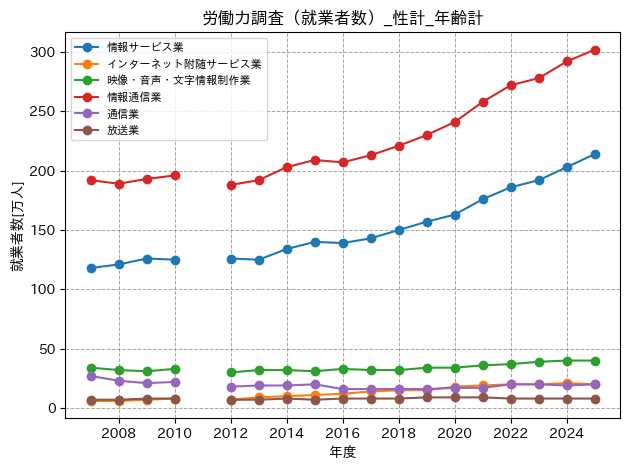

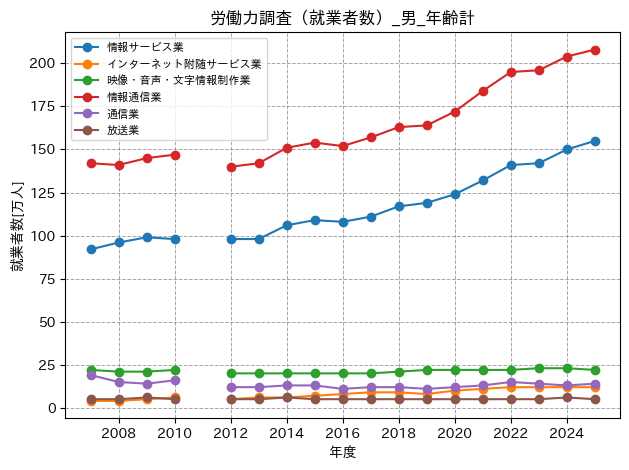

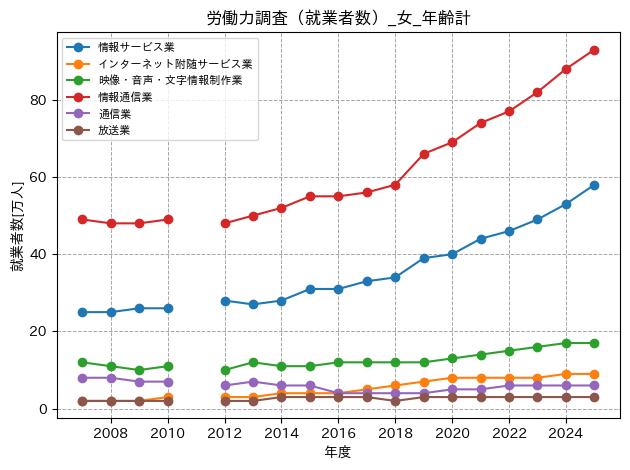

In [9]:
data_name = 'laborforce_generation_industry_employ'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_list = ['情報サービス業', 'インターネット附随サービス業', '映像・音声・文字情報制作業', '情報通信業', '通信業', '放送業']
    for industry in industry_list:
        industry_code = Content_to_code(data_dict[f'{data_name}_codes_df'], 'industry_name', industry, 'industry_code')

        df_extract = data_dict[f'{data_name}_df']
        df_extract = df_extract[df_extract['sex_code'] == sex_code]
        df_extract = df_extract[df_extract['generation_code'] == generation_code]
        df_extract = df_extract[['sex_code', 'generation_code', 'year', f'job_{industry_code}']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = df_extract[f'job_{industry_code}']

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='就業者数[万人]', 
        path=fig_path
    )


### economic_census_employments

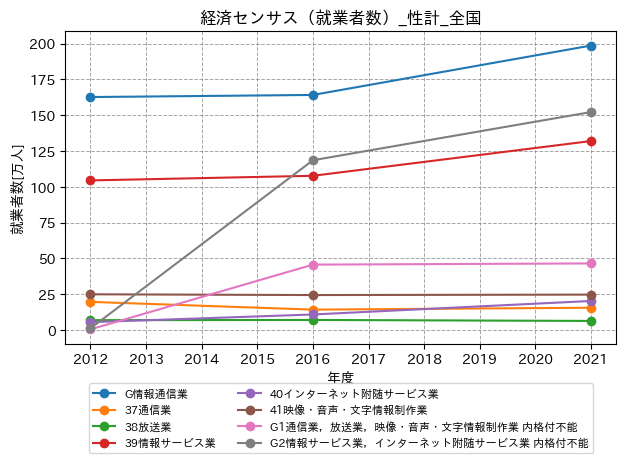

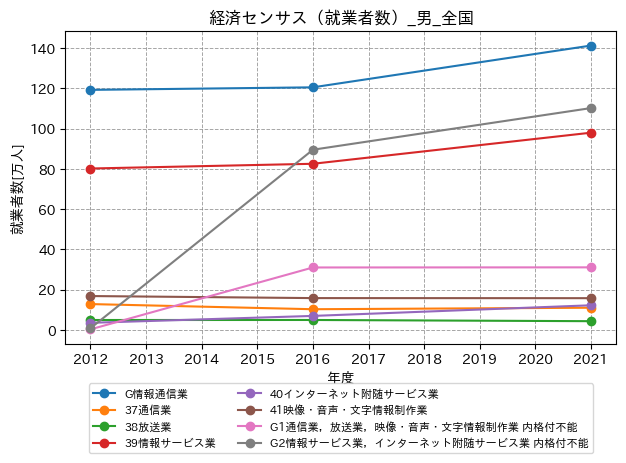

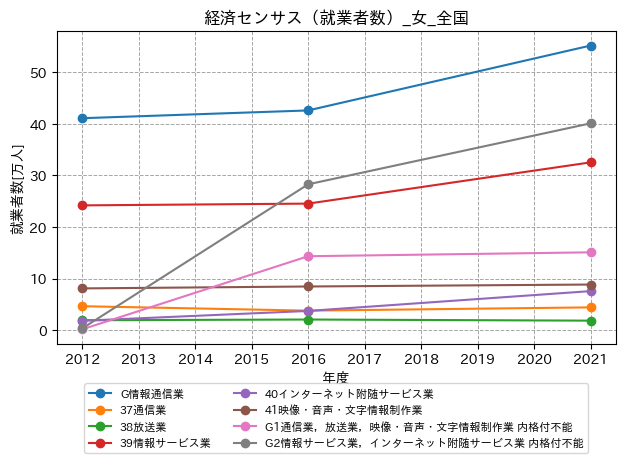

In [10]:
data_name = 'economic_census_employments'

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    if sex == '性計':
        suffix = 't'
    elif sex == '男':
        suffix = 'm'
    elif sex == '女':
        suffix = 'f'

    x_dict = {}
    y_dict = {}

    industry_code_list = [51, 52, 53, 54, 55, 56, 57, 58]
    for industry_code in industry_code_list:
        industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

        df_extract = data_dict[f'{data_name}_df']
        df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
        df_extract = df_extract[df_extract['industry_code'] == industry_code]
        df_extract = df_extract[['prefecture_code', 'year', 'industry_code', f'employments_total_{suffix}']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = [employments / 10000 for employments in df_extract[f'employments_total_{suffix}']]

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{prefecture}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{prefecture}', 
        xlabel='年度', 
        ylabel='就業者数[万人]', 
        legend_bottom=True,
        path=fig_path
    )


## 両テーブルの整合性確認

laborforce_generation_industry_employとeconomic_census_employmentsの産業区分が完全に一致していないので、類似分類の内容が実際に等しいかを確認。

In [11]:
# 両テーブルの結果の比較用に個別の結果を格納する辞書作成
compare_dict = {}

# 経済センサスの結果取得用のパラメータ指定
data_name = 'economic_census_employments'
year_list = [int(year) for year in data_dict[f'{data_name}_df']['year'].unique()]
prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')
sex_list = ['性計', '男', '女']

# 結果取得、compare_dictへの格納のループ
for year in year_list:
    for sex in sex_list:
        if sex == '性計':
            suffix = 't'
        elif sex == '男':
            suffix = 'm'
        elif sex == '女':
            suffix = 'f'

        industry_code_list = [2, 51, 52, 53, 54, 55, 56, 57, 58]
        for industry_code in industry_code_list:
            industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

            df_extract = data_dict[f'{data_name}_df']
            df_extract = df_extract[df_extract['year'] == year]
            df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
            df_extract = df_extract[df_extract['industry_code'] == industry_code]
            compare_dict[f'{name_dict[data_name]}_{sex}_{year}_{industry}'] = float(df_extract[f'employments_total_{suffix}'][:1].values[0]) / 10000

# 労働力調査の結果取得用のパラメータ指定
data_name = 'laborforce_generation_industry_employ'
generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')
sex_list = ['性計', '男', '女']

# 結果取得、compare_dictへの格納のループ
for year in year_list:
    for sex in sex_list:
        sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

        industry_list = ['全産業', '情報サービス業', 'インターネット附随サービス業', '映像・音声・文字情報制作業', '情報通信業', '通信業', '放送業']
        for industry in industry_list:
            industry_code = Content_to_code(data_dict[f'{data_name}_codes_df'], 'industry_name', industry, 'industry_code')

            df_extract = data_dict[f'{data_name}_df']
            df_extract = df_extract[df_extract['year'] == year]
            df_extract = df_extract[df_extract['sex_code'] == sex_code]
            df_extract = df_extract[df_extract['generation_code'] == generation_code]
            compare_dict[f'{name_dict[data_name]}_{sex}_{year}_{industry}'] = float(df_extract[f'job_{industry_code}'][:1].values[0])

print(compare_dict)

{'経済センサス（就業者数）_性計_2012_A～R全産業（Ｓ公務を除く）': 5583.7252, '経済センサス（就業者数）_性計_2012_G情報通信業': 162.731, '経済センサス（就業者数）_性計_2012_37通信業': 19.6034, '経済センサス（就業者数）_性計_2012_38放送業': 6.8217, '経済センサス（就業者数）_性計_2012_39情報サービス業': 104.4779, '経済センサス（就業者数）_性計_2012_40インターネット附随サービス業': 5.4161, '経済センサス（就業者数）_性計_2012_41映像・音声・文字情報制作業': 24.897, '経済センサス（就業者数）_性計_2012_G1通信業，放送業，映像・音声・文字情報制作業 内格付不能': 0.3959, '経済センサス（就業者数）_性計_2012_G2情報サービス業，インターネット附随サービス業 内格付不能': 1.119, '経済センサス（就業者数）_男_2012_A～R全産業（Ｓ公務を除く）': 3135.5187, '経済センサス（就業者数）_男_2012_G情報通信業': 119.2715, '経済センサス（就業者数）_男_2012_37通信業': 12.8186, '経済センサス（就業者数）_男_2012_38放送業': 4.8981, '経済センサス（就業者数）_男_2012_39情報サービス業': 80.1926, '経済センサス（就業者数）_男_2012_40インターネット附随サービス業': 3.4987, '経済センサス（就業者数）_男_2012_41映像・音声・文字情報制作業': 16.8078, '経済センサス（就業者数）_男_2012_G1通信業，放送業，映像・音声・文字情報制作業 内格付不能': 0.2507, '経済センサス（就業者数）_男_2012_G2情報サービス業，インターネット附随サービス業 内格付不能': 0.805, '経済センサス（就業者数）_女_2012_A～R全産業（Ｓ公務を除く）': 2430.2231, '経済センサス（就業者数）_女_2012_G情報通信業': 41.0999, '経済センサス（就業者数）_女_2012_37通信業': 4.6354, '経済センサス（就業者数）_女_20

In [12]:
for sex in sex_list:
    for year in year_list:
        print(f"==================== sex: {sex}, year: {year} ====================")
        for key, value in compare_dict.items():
            if (sex in key) and (str(year) in key):
                print(f"{key}: {value}")

==================== sex: 性計, year: 2012 ====================
経済センサス（就業者数）_性計_2012_A～R全産業（Ｓ公務を除く）: 5583.7252
経済センサス（就業者数）_性計_2012_G情報通信業: 162.731
経済センサス（就業者数）_性計_2012_37通信業: 19.6034
経済センサス（就業者数）_性計_2012_38放送業: 6.8217
経済センサス（就業者数）_性計_2012_39情報サービス業: 104.4779
経済センサス（就業者数）_性計_2012_40インターネット附随サービス業: 5.4161
経済センサス（就業者数）_性計_2012_41映像・音声・文字情報制作業: 24.897
経済センサス（就業者数）_性計_2012_G1通信業，放送業，映像・音声・文字情報制作業 内格付不能: 0.3959
経済センサス（就業者数）_性計_2012_G2情報サービス業，インターネット附随サービス業 内格付不能: 1.119
労働力調査（就業者数）_性計_2012_全産業: 6270.0
労働力調査（就業者数）_性計_2012_情報サービス業: 126.0
労働力調査（就業者数）_性計_2012_インターネット附随サービス業: 7.0
労働力調査（就業者数）_性計_2012_映像・音声・文字情報制作業: 30.0
労働力調査（就業者数）_性計_2012_情報通信業: 188.0
労働力調査（就業者数）_性計_2012_通信業: 18.0
労働力調査（就業者数）_性計_2012_放送業: 7.0
==================== sex: 性計, year: 2016 ====================
経済センサス（就業者数）_性計_2016_A～R全産業（Ｓ公務を除く）: 5687.2826
経済センサス（就業者数）_性計_2016_G情報通信業: 164.2042
経済センサス（就業者数）_性計_2016_37通信業: 14.191
経済センサス（就業者数）_性計_2016_38放送業: 6.9718
経済センサス（就業者数）_性計_2016_39情報サービス業: 107.7081
経済センサス（就業者数）_性計_2016_40インターネット附随サービス

# 推計モデル作成

## 労働力調査による就業者数から都道府県別の値を推計

### 都道府県別人数割合

In [13]:
# 人口動態テーブルから、都道府県単位でないレコード（政令市、外国、不明など）を除外
data_dict['population_weight_df'] = data_dict['population_curated_df'][data_dict['population_curated_df']['prefecture_code']<=47]
# 都道府県コード、年度、人口以外のカラムを除外
data_dict['population_weight_df'] = data_dict['population_weight_df'][['prefecture_code', 'year', 'population']]
# 各年度での全国の人口に対する割合を計算して、population_ratioカラムに追加
# data_dict['population_weight_df']['population_ratio'] = (data_dict['population_weight_df'].groupby('year')['population'].transform(lambda x: x / x.sum()))

# 年度ごとの全国合計値を取得
year_totals = (
    data_dict['population_weight_df'][data_dict['population_weight_df']['prefecture_code'] == 0]
    .set_index('year')['population']
)
# 各行に年度の全国合計値を対応付け
data_dict['population_weight_df']['year_total'] = data_dict['population_weight_df']['year'].map(year_totals)
# 割合を計算
data_dict['population_weight_df']['population_ratio'] = data_dict['population_weight_df']['population'] / data_dict['population_weight_df']['year_total']

# 命名対応辞書に作成テーブルを追加
name_dict['population_weight'] = '都道府県別人口割合テーブル'

### 都道府県別の値を算出

In [14]:
# 労働力調査のテーブルから世代を「年齢計」に絞り、対象産業を['全産業', '情報サービス業', 'インターネット附随サービス業', '映像・音声・文字情報制作業', '情報通信業', '通信業', '放送業']に限定したテーブルを抽出
# テーブル名指定
data_name = 'laborforce_generation_industry_employ'
# 年代のコード指定
generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')
# 性別のコード指定
sex_list = ['性計', '男', '女']
sex_code_list = []
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')
    sex_code_list.append(sex_code)
# 対象産業に合わせてカラム指定
industry_list = ['全産業', '情報サービス業', 'インターネット附随サービス業', '映像・音声・文字情報制作業', '情報通信業', '通信業', '放送業']
industry_column_list = []
for industry in industry_list:
    industry_code = Content_to_code(data_dict[f'{data_name}_codes_df'], 'industry_name', industry, 'industry_code')
    industry_column_list.append(f'job_{industry_code}')

# 指定した条件でテーブルを抽出
df_extract = data_dict[f'{data_name}_df']
df_extract = df_extract[df_extract['generation_code'] == generation_code]
df_extract = df_extract[df_extract['sex_code'].isin(sex_code_list)]
df_extract = df_extract[['year', 'sex_code', 'generation_code'] + industry_column_list]
data_dict['laborforce_generation_industry_employ_prefecture_df'] = df_extract

# 都道府県別の結果を算出するために、都道府県コードを追加して47都道府県分をループして縦結合
data_dict['laborforce_generation_industry_employ_prefecture_df']['prefecture_code'] = 0
prefecture_df_org = data_dict['laborforce_generation_industry_employ_prefecture_df'].copy()
prefecture_code_list = list(range(1, 48))
for prefecture_code in prefecture_code_list:
    prefecture_df = prefecture_df_org.copy()
    prefecture_df['prefecture_code'] = prefecture_code
    data_dict['laborforce_generation_industry_employ_prefecture_df'] = pd.concat([data_dict['laborforce_generation_industry_employ_prefecture_df'], prefecture_df],
                                                                                 axis=0,
                                                                                 ignore_index=True)
del prefecture_df, prefecture_df_org

# 都道府県別人数割合のテーブルをleft join（キーはprefecture_codeとyear）
data_dict['laborforce_generation_industry_employ_prefecture_df'] = pd.merge(data_dict['laborforce_generation_industry_employ_prefecture_df'], 
                                                                            data_dict['population_weight_df'], 
                                                                            on=['prefecture_code', 'year'])

# 各レコードでindustry_column_listのカラムの値にpopulation_ratioの値をかけて都道府県別の就業者数を推計
for industry_column in industry_column_list:
    data_dict['laborforce_generation_industry_employ_prefecture_df'][industry_column] = data_dict['laborforce_generation_industry_employ_prefecture_df'][industry_column]*data_dict['laborforce_generation_industry_employ_prefecture_df']['population_ratio']

# 命名対応辞書に作成テーブルを追加
name_dict['laborforce_generation_industry_employ_prefecture'] = '都道府県別推計労働力調査（就業者数）'

## 2024年の就業者数の真値を推計

経済センサスの最新データは2021年で、今回の推計モデルではそれ以降の年度の推計が出来ない。  
よって、2024年の就業者数を別方法で推計し、それを真値として扱うことで推計モデルを機能させる。  
ここで、真値は都道府県別での値の算出が必要だが、都道府県別での値を直接求められるのは経済センサスのみであり、人口割合のデータは最新でも2024年までしか取得できていないので、推計する真値も2024年のものとする。

2024年の就業者数の推計には、経済センサス実施年の経済センサスと労働力調査の類似産業分類の就業者数の比（調査差分比）を用いる。  
類似産業分類の対応関係は以下とする。  
調査差分比は簡単のために「全国」「性計」「全年代」のみで集計する。

| 経済センサス（2012年）の産業分類 | 労働力調査の産業分類 |
|--------------------------------|--------------------|
| A～R全産業（Ｓ公務を除く） | 全産業 |
| G情報通信業 | 情報通信業 |
| 37通信業 | 通信業 |
| 38放送業 | 放送業 |
| 39情報サービス業 | 情報サービス業 |
| 40インターネット附随サービス業 | インターネット附随サービス業 |
| 41映像・音声・文字情報制作業 | 映像・音声・文字情報制作業 |
| G1通信業，放送業，映像・音声・文字情報制作業 内格付不能 | |
| G2情報サービス業，インターネット附随サービス業 内格付不能 | |

### 2012年、2016年、2021年の調査差分比分布の確認

#### 調査差分比分布算出

In [63]:
x_dict = {}
y_dict_census = {}
y_dict_labor = {}
y_dict_ratio = {}
year_list = [2012, 2016, 2021]
sex_code = 0
generation_code = 0
employments_column = 'employments_total_t'
prefecture_code = 0
census_labor_industry_dict = {
    'A～R全産業（Ｓ公務を除く）':'全産業',
    'G情報通信業':'情報通信業',
    '37通信業':'通信業',
    '38放送業':'放送業',
    '39情報サービス業':'情報サービス業',
    '40インターネット附随サービス業':'インターネット附随サービス業',
    '41映像・音声・文字情報制作業':'映像・音声・文字情報制作業',
}
for census_industry, labor_industry in census_labor_industry_dict.items():
    x_dict[census_industry] = year_list
    y_dict_census[census_industry] = []
    y_dict_labor[census_industry] = []
    y_dict_ratio[census_industry] = []

    for year in year_list:
        census_industry_code = Content_to_code(data_dict['economic_census_code_df'], 'job_name_2012', census_industry, 'job_code')
        labor_industry_code = Content_to_code(data_dict['laborforce_generation_industry_employ_codes_df'], 'industry_name', labor_industry, 'industry_code')

        census_df = data_dict['economic_census_employments_df'][data_dict['economic_census_employments_df']['prefecture_code']==prefecture_code]
        census_df = census_df[census_df['year']==year]
        census_value = float(census_df[census_df['industry_code']==census_industry_code][employments_column][:1].values[0])

        labor_df = data_dict['laborforce_generation_industry_employ_df'][data_dict['laborforce_generation_industry_employ_df']['sex_code']==sex_code]
        labor_df = labor_df[labor_df['generation_code']==generation_code]
        labor_value = float(labor_df[labor_df['year']==year][f'job_{labor_industry_code}'][:1].values[0])
        labor_value = labor_value * 10000

        value_ratio = census_value / labor_value

        y_dict_census[census_industry].append(census_value)
        y_dict_labor[census_industry].append(labor_value)
        y_dict_ratio[census_industry].append(value_ratio)

del census_df, labor_df

#### 調査差分比分布の可視化

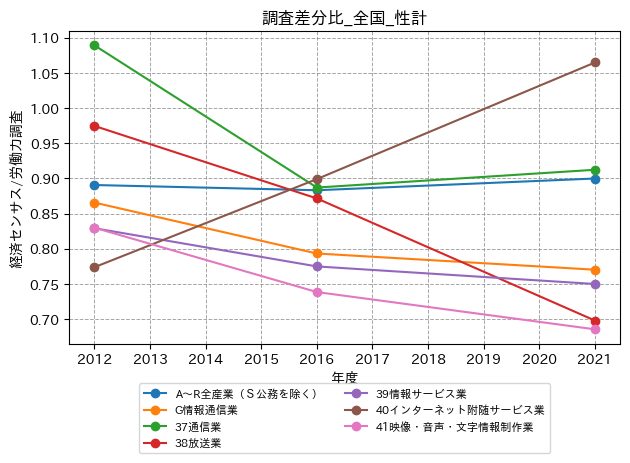

In [64]:
fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_調査差分比.png')
Make_line_plot(
    x_dict, 
    y_dict_ratio, 
    x_integer=True, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title=f'調査差分比_全国_性計', 
    xlabel='年度', 
    ylabel='経済センサス/労働力調査', 
    legend_bottom=True,
    path=fig_path
)

### 2024年の調査差分比の推計
上記の調査差分比の推移より、2024年の調査差分比は以下のように算出する。
- 2012~2016年の調査差分比の傾きを算出（傾き1）
- 2016~2021年の調査差分比の傾きを算出（傾き2）
- 2021~2024年の調査差分比の傾きは```傾き1×0.3 + 傾き1×0.7```で仮定（より直近の傾きを強めに反映。3:7の割合は適当）
- 2021~2024年の重み付き傾きを用いて、2021年の調査差分比から算出

#### 2021~2024年の重み付き傾き算出

In [17]:
# 重み付き平均により2021~2024年の傾き推計
tilt_dict = {}
for key in y_dict_ratio.keys():
    tilt_dict[key] = []
    tilt_dict[key].append((y_dict_ratio[key][1]-y_dict_ratio[key][0])/(2016-2012))
    tilt_dict[key].append((y_dict_ratio[key][2]-y_dict_ratio[key][1])/(2021-2016))
    tilt_dict[key].append(0.3*tilt_dict[key][0] + 0.7*tilt_dict[key][1])

tilt_dict

{'A～R全産業（Ｓ公務を除く）': [-0.0018569669356196805,
  0.0033347615787667094,
  0.001777243024450792],
 'G情報通信業': [-0.018083355175249255,
  -0.004609695539826997,
  -0.008651793430453674],
 '37通信業': [-0.05053506944444444, 0.005056029411764707, -0.011621300245098037],
 '38放送業': [-0.025763392857142853, -0.034706111111111104, -0.03202329563492063],
 '39情報サービス業': [-0.013577816318373875,
  -0.004993978907782859,
  -0.007569130130960163],
 '40インターネット附随サービス業': [0.03131369047619048,
  0.033133859649122785,
  0.03258780889724309],
 '41映像・音声・文字情報制作業': [-0.022856818181818173,
  -0.010591767676767682,
  -0.014271282828282827]}

#### 2024年の推計調査差分比算出

In [18]:
# 2021~2024年の推計傾きより2024年の推計調査差分比を算出
for key in y_dict_ratio.keys():
    y_dict_ratio[key].append(y_dict_ratio[key][2]+tilt_dict[key][2]*(2024-2021))

y_dict_ratio

{'A～R全産業（Ｓ公務を除く）': [0.890546283891547,
  0.8831184161490683,
  0.8997922240429018,
  0.9051239531162542],
 'G情報通信業': [0.8655904255319149,
  0.7932570048309179,
  0.7702085271317829,
  0.7442531468404219],
 '37通信業': [1.0890777777777778,
  0.8869375,
  0.9122176470588236,
  0.8773537463235295],
 '38放送業': [0.9745285714285714,
  0.871475,
  0.6979444444444445,
  0.6018745575396826],
 '39情報サービス業': [0.8291896825396825,
  0.774878417266187,
  0.7499085227272727,
  0.7272011323343922],
 '40インターネット附随サービス業': [0.7737285714285714,
  0.8989833333333334,
  1.0646526315789473,
  1.1624160582706766],
 '41映像・音声・文字情報制作業': [0.8299,
  0.7384727272727273,
  0.6855138888888889,
  0.6427000404040404]}

#### 2024年の就業者数の真値を推計

In [19]:
# 2024年の推計調査差分比を用いて2024年の就業者数の真値を推計
census_2024_dict = {}
labor_2024_df = data_dict['laborforce_generation_industry_employ_df'][data_dict['laborforce_generation_industry_employ_df']['generation_code']==0]
labor_2024_df = labor_2024_df[labor_2024_df['year']==2024]
population_weight_df = data_dict['population_weight_df'][data_dict['population_weight_df']['year']==2024]
population_weight_df = population_weight_df[['prefecture_code', 'population_ratio']]
for key in y_dict_ratio.keys():
    labor_industry = census_labor_industry_dict[key]
    labor_industry_code = Content_to_code(data_dict['laborforce_generation_industry_employ_codes_df'], 'industry_name', labor_industry, 'industry_code')

    census_2024_dict[f'industry_code_{labor_industry_code}'] = {}
    for prefecture_code in list(range(0, 48)):
        census_2024_dict[f'industry_code_{labor_industry_code}'][f'prefecture_code_{prefecture_code}'] = {}
        population_ratio = float(population_weight_df[population_weight_df['prefecture_code']==prefecture_code]['population_ratio'][:1].values[0])

        for sex_code in list(range(0, 3)):
            labor_2024 = labor_2024_df[labor_2024_df['sex_code']==sex_code]
            labor_2024 = float(labor_2024[f'job_{labor_industry_code}'][:1].values[0])*10000*population_ratio
            census_2024_dict[f'industry_code_{labor_industry_code}'][f'prefecture_code_{prefecture_code}'][f'sex_code_{sex_code}'] = labor_2024*y_dict_ratio[key][3]

del labor_2024_df, population_weight_df

## 経済センサス間の就業者数の差分算出

In [20]:
# 都道府県別の労働力調査推計結果からウェイトを算出するためのデータフレーム作成
economic_census_employments_df_org = data_dict['economic_census_employments_df'].copy()
census_df_2012 = economic_census_employments_df_org[economic_census_employments_df_org['year']==2012].reset_index(drop=True)
census_df_2016 = economic_census_employments_df_org[economic_census_employments_df_org['year']==2016].reset_index(drop=True)
census_df_2021 = economic_census_employments_df_org[economic_census_employments_df_org['year']==2021].reset_index(drop=True)
# 次の経済センサス実施年との差分を算出。
census_df_2012['diff_census_t'] = census_df_2016['employments_total_t'] - census_df_2012['employments_total_t']
census_df_2012['diff_census_m'] = census_df_2016['employments_total_m'] - census_df_2012['employments_total_m']
census_df_2012['diff_census_f'] = census_df_2016['employments_total_f'] - census_df_2012['employments_total_f']
census_df_2016['diff_census_t'] = census_df_2021['employments_total_t'] - census_df_2016['employments_total_t']
census_df_2016['diff_census_m'] = census_df_2021['employments_total_m'] - census_df_2016['employments_total_m']
census_df_2016['diff_census_f'] = census_df_2021['employments_total_f'] - census_df_2016['employments_total_f']
# 2021年から見た次の経済センサス実施年は本来は2026年だが、現状2026年のデータは無いので、2024年の推計真値で代用する
census_df_2021['diff_census_t'] = 0.0
census_df_2021['diff_census_m'] = 0.0
census_df_2021['diff_census_f'] = 0.0
for census_industry, labor_industry in census_labor_industry_dict.items():
    for year in year_list:
        census_industry_code = Content_to_code(data_dict['economic_census_code_df'], 'job_name_2012', census_industry, 'job_code')
        labor_industry_code = Content_to_code(data_dict['laborforce_generation_industry_employ_codes_df'], 'industry_name', labor_industry, 'industry_code')
        for prefecture_code in list(range(0, 48)):
            df_extract = census_df_2021.query(f'prefecture_code=={prefecture_code} and industry_code=={census_industry_code}')
            index_num = df_extract.index[0]
            column_num = df_extract.columns.get_loc('diff_census_t')
            census_df_2021.iat[index_num, column_num] = census_2024_dict[f'industry_code_{labor_industry_code}'][f'prefecture_code_{prefecture_code}']['sex_code_0'] - float(df_extract['employments_total_t'][:1].values[0])
            column_num = df_extract.columns.get_loc('diff_census_m')
            census_df_2021.iat[index_num, column_num] = census_2024_dict[f'industry_code_{labor_industry_code}'][f'prefecture_code_{prefecture_code}']['sex_code_1'] - float(df_extract['employments_total_m'][:1].values[0])
            column_num = df_extract.columns.get_loc('diff_census_f')
            census_df_2021.iat[index_num, column_num] = census_2024_dict[f'industry_code_{labor_industry_code}'][f'prefecture_code_{prefecture_code}']['sex_code_2'] - float(df_extract['employments_total_f'][:1].values[0])

# 2012年のテーブルをウェイト算出用に整形
census_df_2012['sex_code'] = 0
# 性計
census_df_t = census_df_2012[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_t', 'diff_census_t']]
census_df_t = census_df_t.rename(columns={'employments_total_t':'employments_total', 'diff_census_t':'diff_census'})
# 男性
census_df_m = census_df_2012[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_m', 'diff_census_m']]
census_df_m = census_df_m.rename(columns={'employments_total_m':'employments_total', 'diff_census_m':'diff_census'})
census_df_m['sex_code'] = 1
# 女性
census_df_f = census_df_2012[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_f', 'diff_census_f']]
census_df_f = census_df_f.rename(columns={'employments_total_f':'employments_total', 'diff_census_f':'diff_census'})
census_df_f['sex_code'] = 2
census_df = pd.concat([census_df_t, census_df_m, census_df_f], axis=0, ignore_index=True)
# data_dictに格納（以降の年度分は縦結合するので、この操作は2012年のみ）
data_dict['economic_census_employments_estimate_df'] = census_df.copy()
# 2016年までは2012年の整形後テーブルをコピーして縦結合
for year in [2013, 2014, 2015]:
    census_df_n = census_df.copy()
    census_df_n['year'] = year
    data_dict['economic_census_employments_estimate_df'] = pd.concat([data_dict['economic_census_employments_estimate_df'], census_df_n],
                                                                     axis=0, 
                                                                     ignore_index=True)

# 2016年のテーブルをウェイト算出用に整形
census_df_2016['sex_code'] = 0
# 性計
census_df_t = census_df_2016[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_t', 'diff_census_t']]
census_df_t = census_df_t.rename(columns={'employments_total_t':'employments_total', 'diff_census_t':'diff_census'})
# 男性
census_df_m = census_df_2016[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_m', 'diff_census_m']]
census_df_m = census_df_m.rename(columns={'employments_total_m':'employments_total', 'diff_census_m':'diff_census'})
census_df_m['sex_code'] = 1
# 女性
census_df_f = census_df_2016[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_f', 'diff_census_f']]
census_df_f = census_df_f.rename(columns={'employments_total_f':'employments_total', 'diff_census_f':'diff_census'})
census_df_f['sex_code'] = 2
census_df = pd.concat([census_df_t, census_df_m, census_df_f], axis=0, ignore_index=True)
# 2016年の整形後テーブルを縦結合
data_dict['economic_census_employments_estimate_df'] = pd.concat([data_dict['economic_census_employments_estimate_df'], census_df],
                                                                axis=0, 
                                                                ignore_index=True)
# 2020年までは2016年の整形後テーブルをコピーして縦結合
for year in [2017, 2018, 2019, 2020]:
    census_df_n = census_df.copy()
    census_df_n['year'] = year
    data_dict['economic_census_employments_estimate_df'] = pd.concat([data_dict['economic_census_employments_estimate_df'], census_df_n],
                                                                     axis=0, 
                                                                     ignore_index=True)

# 2021年のテーブルをウェイト算出用に整形
census_df_2021['sex_code'] = 0
# 性計
census_df_t = census_df_2021[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_t', 'diff_census_t']]
census_df_t = census_df_t.rename(columns={'employments_total_t':'employments_total', 'diff_census_t':'diff_census'})
# 男性
census_df_m = census_df_2021[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_m', 'diff_census_m']]
census_df_m = census_df_m.rename(columns={'employments_total_m':'employments_total', 'diff_census_m':'diff_census'})
census_df_m['sex_code'] = 1
# 女性
census_df_f = census_df_2021[['prefecture_code', 'year', 'sex_code', 'industry_code', 'employments_total_f', 'diff_census_f']]
census_df_f = census_df_f.rename(columns={'employments_total_f':'employments_total', 'diff_census_f':'diff_census'})
census_df_f['sex_code'] = 2
census_df = pd.concat([census_df_t, census_df_m, census_df_f], axis=0, ignore_index=True)
# 2021年の整形後テーブルを縦結合
data_dict['economic_census_employments_estimate_df'] = pd.concat([data_dict['economic_census_employments_estimate_df'], census_df],
                                                                axis=0, 
                                                                ignore_index=True)
# 2025年までは2021年の整形後テーブルをコピーして縦結合
for year in [2022, 2023, 2024, 2025]:
    census_df_n = census_df.copy()
    census_df_n['year'] = year
    data_dict['economic_census_employments_estimate_df'] = pd.concat([data_dict['economic_census_employments_estimate_df'], census_df_n],
                                                                     axis=0, 
                                                                     ignore_index=True)

# 命名対応辞書に作成テーブルを追加
name_dict['economic_census_employments_estimate'] = '推計経済センサス（就業者数）'

del economic_census_employments_df_org, census_df_2012, census_df_2016, census_df_2021, df_extract, census_df, census_df_t, census_df_m, census_df_f, census_df_n 

In [21]:
data_dict['economic_census_employments_estimate_df']

,prefecture_code,year,sex_code,industry_code,employments_total,diff_census
0,0,2012,0,2,55837252.0,1.035574e+06
1,0,2012,0,51,1627310.0,1.473200e+04
2,0,2012,0,52,196034.0,-5.412400e+04
3,0,2012,0,53,68217.0,1.501000e+03
4,0,2012,0,54,1044779.0,3.230200e+04
...,...,...,...,...,...,...
18139,47,2025,2,54,2611.0,1.993023e+03
18140,47,2025,2,55,1079.0,1.707155e+02
18141,47,2025,2,56,582.0,7.231616e+02
18142,47,2025,2,57,1380.0,0.000000e+00


## ウェイト算出

### 労働力調査基準の就業者数の経年変化算出（ウェイトの分子）

#### 推計労働力調査の就業者数を取得

In [22]:
# 都道府県別の推計労働力調査のテーブルから必要な情報を抽出
prefecture_code_list = [int(code) for code in data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()]
year_list = [int(code) for code in data_dict['economic_census_employments_estimate_df']['year'].unique()]
sex_dict = {0:'t', 1:'m', 2:'f'}
sex_list = list(sex_dict.keys())
generation_code = 0
labor_industry_column_list = []
census_industry_code_list = []
for census_industry, labor_industry in census_labor_industry_dict.items():
    census_industry_code = Content_to_code(data_dict['economic_census_code_df'], 'job_name_2012', census_industry, 'job_code')
    labor_industry_code = Content_to_code(data_dict['laborforce_generation_industry_employ_codes_df'], 'industry_name', labor_industry, 'industry_code')
    census_industry_code_list.append(census_industry_code)
    labor_industry_column_list.append(f'job_{labor_industry_code}')
labor_diff_df = data_dict['laborforce_generation_industry_employ_prefecture_df'].query(f'generation_code == {generation_code}')
labor_diff_df = labor_diff_df[['year', 'sex_code', 'prefecture_code']+labor_industry_column_list]
labor_diff_df_org = labor_diff_df.copy()
labor_diff_df_total = None

# 推計労働力調査のテーブルに合わせて推計経済センサステーブルのレコードを制限
data_dict['economic_census_employments_estimate_df'] = data_dict['economic_census_employments_estimate_df'].query('year <= 2024')
data_dict['economic_census_employments_estimate_df'] = data_dict['economic_census_employments_estimate_df'][data_dict['economic_census_employments_estimate_df']['industry_code'].isin(census_industry_code_list)].reset_index(drop=True)

# 推計労働力調査のテーブルから抽出した情報を推計経済センサステーブルの形式に合わせる。
for census_industry, labor_industry in census_labor_industry_dict.items():
    census_industry_code = Content_to_code(data_dict['economic_census_code_df'], 'job_name_2012', census_industry, 'job_code')
    labor_industry_code = Content_to_code(data_dict['laborforce_generation_industry_employ_codes_df'], 'industry_name', labor_industry, 'industry_code')

    if labor_diff_df_total is None:
        labor_diff_df_total = labor_diff_df_org[['year', 'sex_code', 'prefecture_code', f'job_{labor_industry_code}']]
        labor_diff_df_total = labor_diff_df_total.rename(columns={f'job_{labor_industry_code}':'labors_total'})
        labor_diff_df_total['labors_total'] = labor_diff_df_total['labors_total']*10000
        # この後の紐づけ処理のために、industry_codeは経済センサス側の値を振る
        labor_diff_df_total['industry_code'] = census_industry_code 
    else:
        labor_diff_df = labor_diff_df_org[['year', 'sex_code', 'prefecture_code', f'job_{labor_industry_code}']]
        labor_diff_df = labor_diff_df.rename(columns={f'job_{labor_industry_code}':'labors_total'})
        labor_diff_df['labors_total'] = labor_diff_df['labors_total']*10000
        # この後の紐づけ処理のために、industry_codeは経済センサス側の値を振る
        labor_diff_df['industry_code'] = census_industry_code
        labor_diff_df_total = pd.concat([labor_diff_df_total, labor_diff_df], axis=0, ignore_index=True)

# 推計経済センサステーブルに推計労働力調査の整形テーブルをleft join（キーはprefecture_code、year、sex_code、industry_code）
data_dict['economic_census_employments_estimate_df'] = pd.merge(data_dict['economic_census_employments_estimate_df'], 
                                                                labor_diff_df_total, 
                                                                on=['prefecture_code', 'year', 'sex_code', 'industry_code'])


del labor_diff_df_org, labor_diff_df, labor_diff_df_total


#### 推計労働力調査の就業者数の前年からの差分（経年変化）を算出

In [23]:
# 見やすさのためにカラム順を変更
data_dict['economic_census_employments_estimate_df'] = data_dict['economic_census_employments_estimate_df'][['industry_code', 'prefecture_code', 'sex_code', 'year', 'employments_total', 'diff_census', 'labors_total']]
# 前年度の値との差分を計算するので、'industry_code' → 'prefecture_code' → 'sex_code' → 'year'の優先度で昇順に並び替え
data_dict['economic_census_employments_estimate_df'] = data_dict['economic_census_employments_estimate_df'].sort_values(['sex_code', 'prefecture_code', 'industry_code'], ignore_index=True)
data_dict['economic_census_employments_estimate_df']['labor_diff_before'] = data_dict['economic_census_employments_estimate_df']['labors_total'].diff()
# 2012年は前年の値が無いので0に書き換える（自動だとNanもしくは別カテゴリの2024年の値との差を算出）
index_num_list = list(data_dict['economic_census_employments_estimate_df'].query('year==2012').index)
column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_before')
for index_num in index_num_list:
    data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = 0.0


### 経済センサス実施年での労働力調査基準の就業者数の経年変化算出（ウェイトの分母）

#### 2012 → 2016年の変化

In [24]:
# 4年前との差分用のカラム作成（4年間のトータルの変分が0になる場合を避けるために、算出にはlabor_diff_beforeの絶対値の4年分の和を用いる）
data_dict['economic_census_employments_estimate_df']['labor_diff_2012-2016'] = 0.0
# 2017年以降は0に書き換える（経済センサス実施年や真値推計年の間隔が4年でないため別で算出）
# index_num_list = list(data_dict['economic_census_employments_estimate_df'].query('year>2016').index)
# column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2012-2016')
# for index_num in index_num_list:
#     data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = 0.0
# 2012~2016年は2016年の値で置換
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            df_extract = data_dict['economic_census_employments_estimate_df'].query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
            index_num_list = list(df_extract.query('year>=2012 and year<=2016').index)
            column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2012-2016')
            # labor_diff_beforeの絶対値の4年分の和を算出（2012年はlabor_diff_beforeが0なので含める必要なし）
            diff_value = 0.0
            for i in [2013, 2014, 2015, 2016]:
                diff_value += abs(float(df_extract.query(f'year=={i}')['labor_diff_before'][:1].values[0]))
            for index_num in index_num_list:
                data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = diff_value

#### 2017 → 2021年の変化

In [25]:
# 5年前との差分用のカラム作成（5年間のトータルの変分が0になる場合を避けるために、算出にはlabor_diff_beforeの絶対値の4年分の和を用いる）
data_dict['economic_census_employments_estimate_df']['labor_diff_2017-2021'] = 0.0
# # 2016年以前と2022年以降は0に書き換える（経済センサス実施年や真値推計年の間隔が4年でないため別で算出）
# index_num_list = list(data_dict['economic_census_employments_estimate_df'].query('year<2017 or year>2021').index)
# column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2017-2021')
# for index_num in index_num_list:
#     data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = 0.0
# # 2017~2021年は2021年の値で置換
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            df_extract = data_dict['economic_census_employments_estimate_df'].query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
            index_num_list = list(df_extract.query('year>=2017 and year<=2021').index)
            column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2017-2021')
            # labor_diff_beforeの絶対値の5年分の和を算出
            diff_value = 0.0
            for i in [2017, 2018, 2019, 2020, 2021]:
                diff_value += abs(float(df_extract.query(f'year=={i}')['labor_diff_before'][:1].values[0]))
            for index_num in index_num_list:
                data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = diff_value

#### 2022 → 2024年の変化

In [26]:
# 3年前との差分用のカラム作成（3年間のトータルの変分が0になる場合を避けるために、算出にはlabor_diff_beforeの絶対値の4年分の和を用いる）
data_dict['economic_census_employments_estimate_df']['labor_diff_2022-2024'] = 0.0
# # 2024年以前は0に書き換える（経済センサス実施年や真値推計年の間隔が4年でないため別で算出）
# index_num_list = list(data_dict['economic_census_employments_estimate_df'].query('year<2022').index)
# column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2022-2024')
# for index_num in index_num_list:
#     data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = 0.0
# # 2022~2024年は2024年の値で置換
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            df_extract = data_dict['economic_census_employments_estimate_df'].query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
            index_num_list = list(df_extract.query('year>=2022 and year<=2024').index)
            column_num = data_dict['economic_census_employments_estimate_df'].columns.get_loc('labor_diff_2022-2024')
            # labor_diff_beforeの絶対値の3年分の和を算出
            diff_value = 0.0
            for i in [2022, 2023, 2024]:
                diff_value += abs(float(df_extract.query(f'year=={i}')['labor_diff_before'][:1].values[0]))
            for index_num in index_num_list:
                data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = diff_value

#### 各スパンの変化を合計して経済センサス実施年での労働力調査基準の就業者数の経年変化算出

それぞれのカラムでは該当スパン以外の値は0としているので、そのまま3つのカラムの値を合計することで経済センサス実施年での労働力調査基準の就業者数の経年変化が算出される。

In [27]:
# 3つのスパンの経年変化カラムの和をとる
data_dict['economic_census_employments_estimate_df']['labor_diff_census'] = \
    data_dict['economic_census_employments_estimate_df']['labor_diff_2012-2016']+\
    data_dict['economic_census_employments_estimate_df']['labor_diff_2017-2021']+\
    data_dict['economic_census_employments_estimate_df']['labor_diff_2022-2024']
# それぞれのスパンのカラムは不要なので削除
data_dict['economic_census_employments_estimate_df'] = Drop_index_column_df(data_dict['economic_census_employments_estimate_df'],
                                                                            drop_index_list=None, 
                                                                            drop_column_list=['labor_diff_2012-2016', 'labor_diff_2017-2021', 'labor_diff_2022-2024'])

### ウェイト算出

#### 個別に算出したウェイトの分母、分子から算出

In [28]:
data_dict['economic_census_employments_estimate_df']['weight_labors'] = \
data_dict['economic_census_employments_estimate_df']['labor_diff_before']/data_dict['economic_census_employments_estimate_df']['labor_diff_census']

#### ウェイトの分母が0の場合の対応

スパン中に労働力調査基準の就業者数の経年変化が0（増減が打ち消しての0ではなく変化自体が無い）の場合、ウェイトの算出が0除算になるので、手動でウェイトを0に書き換える。

In [29]:
null_df = data_dict['economic_census_employments_estimate_df']
index_num_list = list(null_df.query('labor_diff_census==0.0').index)
column_num = null_df.columns.get_loc('weight_labors')
for index_num in index_num_list:
    data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = 0.0

## 経済センサス非実施年の就業者数の推計

推計方法は以下の通り
- 2012年の値は経済センサスの値を用いる
- 2013年以降は```前年の値 + ウェイト × 経済センサスの差分```で算出
- モデルの構造より、2016年、2021年、2024年は推定値と経済センサスの値（または推定真値）が一致するので、補正等は不要

### 就業者数推計

In [30]:
# 2012年の値は経済センサスの値そのままなので、推計値のカラムは経済センサスの値のカラムをコピーし、2012年以外を修正していく。
data_dict['economic_census_employments_estimate_df']['estimate_value'] = data_dict['economic_census_employments_estimate_df']['employments_total']

# カテゴリ（industry_code, prefecture_code, sex_codeの組み合わせ）毎にyearをずらしながら計算していく
# yearは必ず昇順になっていないといけないので、念のためリストで作成し昇順にソート
year_list = sorted([int(year) for year in data_dict['economic_census_employments_estimate_df']['year'].unique()])
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            for year in year_list:
                df_extract = data_dict['economic_census_employments_estimate_df'].query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
                before_year = year - 1
                if year == 2012:
                    pass
                else:
                    index_num = df_extract.query(f'year=={year}').index[0]
                    column_num = df_extract.columns.get_loc('estimate_value')
                    # weight_laborだけは推計値を算出したいレコードに格納された値を用いる。
                    estimate_value = \
                        float(df_extract.query(f'year=={before_year}')['estimate_value'][:1].values[0])+\
                        float(df_extract.query(f'year=={year}')['weight_labors'][:1].values[0])*\
                        float(df_extract.query(f'year=={before_year}')['diff_census'][:1].values[0])
                    data_dict['economic_census_employments_estimate_df'].iat[index_num, column_num] = estimate_value


In [31]:
# 推計経済センサステーブルのカラムと凝集を取得
data_dict['economic_census_employments_estimate_columns'], data_dict['economic_census_employments_estimate_number_of_rows'] = \
    Check_df(data_dict['economic_census_employments_estimate_df'])
# 冒頭30行表示
data_dict['economic_census_employments_estimate_df'].head(30)

データフレームの冒頭5行を表示
   industry_code  prefecture_code  sex_code  year  employments_total  \
0              2                0         0  2012         55837252.0   
1              2                0         0  2013         55837252.0   
2              2                0         0  2014         55837252.0   
3              2                0         0  2015         55837252.0   
4              2                0         0  2016         56872826.0   

   diff_census  labors_total  labor_diff_before  labor_diff_census  \
0    1035574.0    62700000.0                0.0          1700000.0   
1    1035574.0    63110000.0           410000.0          1700000.0   
2    1035574.0    63510000.0           400000.0          1700000.0   
3    1035574.0    63760000.0           250000.0          1700000.0   
4    3530226.0    64400000.0           640000.0          1700000.0   

   weight_labors  estimate_value  
0       0.000000    5.583725e+07  
1       0.241176    5.608701e+07  
2       0.235294    5.633

,industry_code,prefecture_code,sex_code,year,employments_total,diff_census,labors_total,labor_diff_before,labor_diff_census,weight_labors,estimate_value
0,2,0,0,2012,55837252.0,1.035574e+06,62700000.0,0.0,1700000.0,0.000000,5.583725e+07
1,2,0,0,2013,55837252.0,1.035574e+06,63110000.0,410000.0,1700000.0,0.241176,5.608701e+07
2,2,0,0,2014,55837252.0,1.035574e+06,63510000.0,400000.0,1700000.0,0.235294,5.633067e+07
3,2,0,0,2015,55837252.0,1.035574e+06,63760000.0,250000.0,1700000.0,0.147059,5.648296e+07
4,2,0,0,2016,56872826.0,3.530226e+06,64400000.0,640000.0,1700000.0,0.376471,5.687283e+07
5,2,0,0,2017,56872826.0,3.530226e+06,65300000.0,900000.0,3530000.0,0.254958,5.777288e+07
6,2,0,0,2018,56872826.0,3.530226e+06,66820000.0,1520000.0,3530000.0,0.430595,5.929298e+07
7,2,0,0,2019,56872826.0,3.530226e+06,67500000.0,680000.0,3530000.0,0.192635,5.997302e+07
8,2,0,0,2020,56872826.0,3.530226e+06,67100000.0,-400000.0,3530000.0,-0.113314,5.957300e+07
9,2,0,0,2021,60403052.0,9.734033e+05,67130000.0,30000.0,3530000.0,0.008499,5.960300e+07


### 推計構成比（各年度の全就業者数に対する割合）

各年度の「全産業」「全国」「性計」での就業者数に対する、産業分類、都道府県別、性別を指定した場合の割合を抽出。

In [32]:
composition_rate_df = data_dict['economic_census_employments_estimate_df'].copy()
composition_rate_df['composition_rate'] = 0.0

# カテゴリ（industry_code, prefecture_code, sex_codeの組み合わせ）毎にyearをずらしながら計算していく
# yearは必ず昇順になっていないといけないので、念のためリストで作成し昇順にソート
year_list = sorted([int(year) for year in data_dict['economic_census_employments_estimate_df']['year'].unique()])
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            for year in year_list:
                # 基準となる各年度の「全産業（コード値=2）」「全国（コード値=0）」「性計（コード値=0）」での就業者数取得
                total_value = float(composition_rate_df.query(f'year=={year} and industry_code==2 and prefecture_code==0 and sex_code==0')['estimate_value'][:1].values[0])
                # 該当カテゴリでの各年度の推計就業者数取得
                df_extract = composition_rate_df.query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
                composition_value = float(df_extract.query(f'year=={year}')['estimate_value'][:1].values[0])
                # インデックス番号、カラム番号取得
                index_num = df_extract.query(f'year=={year}').index[0]
                column_num = df_extract.columns.get_loc('composition_rate')
                # weight_laborだけは推計値を算出したいレコードに格納された値を用いる。
                composition_rate = composition_value/total_value
                composition_rate_df.iat[index_num, column_num] = composition_rate

data_dict['economic_census_employments_estimate_composition_rate_df'] = composition_rate_df[['industry_code', 'prefecture_code', 'sex_code', 'year', 'estimate_value', 'composition_rate']]


In [33]:
name_dict['economic_census_employments_estimate_composition_rate'] = '推計経済センサス（構成比）'
data_dict['economic_census_employments_estimate_composition_rate_columns'], data_dict['economic_census_employments_estimate_composition_rate_number_of_rows'] = \
    Check_df(data_dict['economic_census_employments_estimate_composition_rate_df'])

データフレームの冒頭5行を表示
   industry_code  prefecture_code  sex_code  year  estimate_value  \
0              2                0         0  2012    5.583725e+07   
1              2                0         0  2013    5.608701e+07   
2              2                0         0  2014    5.633067e+07   
3              2                0         0  2015    5.648296e+07   
4              2                0         0  2016    5.687283e+07   

   composition_rate  
0               1.0  
1               1.0  
2               1.0  
3               1.0  
4               1.0  
データフレームのカラム一覧、カラム数、列数を表示
カラム一覧: ['industry_code', 'prefecture_code', 'sex_code', 'year', 'estimate_value', 'composition_rate']
カラム数: 6
行数: 13104
データフレームの基本情報を表示
<class 'pandas.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   industry_code     13104 non-null  int64  
 1   prefecture_code   13104 non-null 

### 推計経年変化率（カテゴリごとの2012年の就業者数に対する割合）

各カテゴリでの推計就業者の時系列変化を抽出

In [34]:
chronologica_rate_df = data_dict['economic_census_employments_estimate_df'].copy()
chronologica_rate_df['chronologica_rate'] = 0.0

# カテゴリ（industry_code, prefecture_code, sex_codeの組み合わせ）毎にyearをずらしながら計算していく
# yearは必ず昇順になっていないといけないので、念のためリストで作成し昇順にソート
year_list = sorted([int(year) for year in data_dict['economic_census_employments_estimate_df']['year'].unique()])
for industry_code in list(data_dict['economic_census_employments_estimate_df']['industry_code'].unique()):
    for prefecture_code in list(data_dict['economic_census_employments_estimate_df']['prefecture_code'].unique()):
        for sex_code in list(data_dict['economic_census_employments_estimate_df']['sex_code'].unique()):
            # 基準となる2012年度での就業者数取得
            value_2012 = float(chronologica_rate_df.query(f'year==2012 and industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')['estimate_value'][:1].values[0])
            for year in year_list:
                # 該当カテゴリでの各年度の推計就業者数取得
                df_extract = chronologica_rate_df.query(f'industry_code=={industry_code} and prefecture_code=={prefecture_code} and sex_code=={sex_code}')
                chronologica_value = float(df_extract.query(f'year=={year}')['estimate_value'][:1].values[0])
                # インデックス番号、カラム番号取得
                index_num = df_extract.query(f'year=={year}').index[0]
                column_num = df_extract.columns.get_loc('chronologica_rate')
                # weight_laborだけは推計値を算出したいレコードに格納された値を用いる。
                chronologica_rate = chronologica_value/value_2012
                chronologica_rate_df.iat[index_num, column_num] = chronologica_rate

data_dict['economic_census_employments_estimate_chronologica_rate_df'] = chronologica_rate_df[['industry_code', 'prefecture_code', 'sex_code', 'year', 'estimate_value', 'chronologica_rate']]


In [35]:
name_dict['economic_census_employments_estimate_chronologica_rate'] = '推計経済センサス（経年変化率）'
data_dict['economic_census_employments_estimate_chronologica_rate_columns'], data_dict['economic_census_employments_estimate_chronologica_rate_number_of_rows'] = \
    Check_df(data_dict['economic_census_employments_estimate_chronologica_rate_df'])

データフレームの冒頭5行を表示
   industry_code  prefecture_code  sex_code  year  estimate_value  \
0              2                0         0  2012    5.583725e+07   
1              2                0         0  2013    5.608701e+07   
2              2                0         0  2014    5.633067e+07   
3              2                0         0  2015    5.648296e+07   
4              2                0         0  2016    5.687283e+07   

   chronologica_rate  
0           1.000000  
1           1.004473  
2           1.008837  
3           1.011564  
4           1.018546  
データフレームのカラム一覧、カラム数、列数を表示
カラム一覧: ['industry_code', 'prefecture_code', 'sex_code', 'year', 'estimate_value', 'chronologica_rate']
カラム数: 6
行数: 13104
データフレームの基本情報を表示
<class 'pandas.DataFrame'>
RangeIndex: 13104 entries, 0 to 13103
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   industry_code      13104 non-null  int64  
 1   prefecture_code    1310

## 結果の可視化

### 就業者数推計

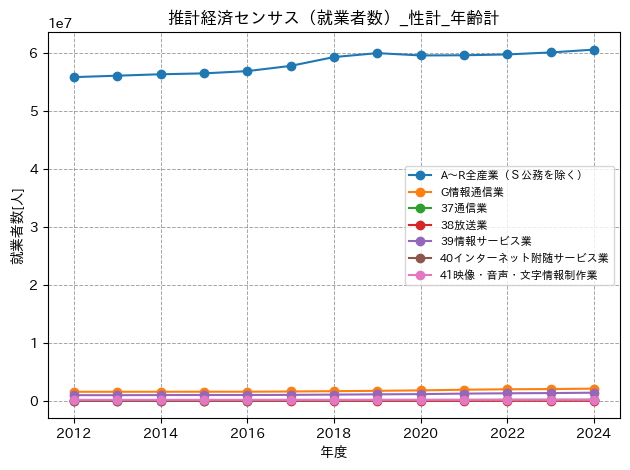

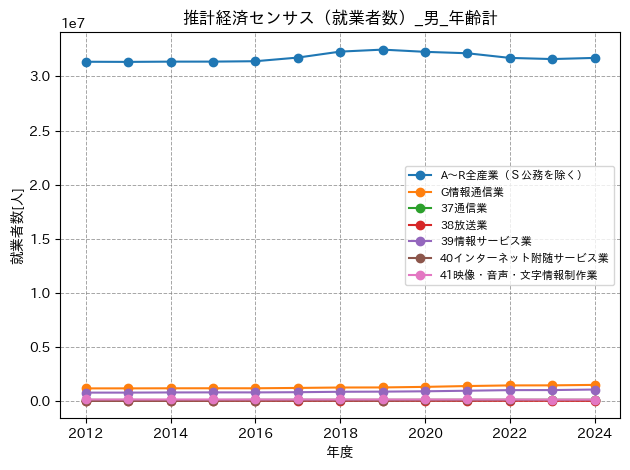

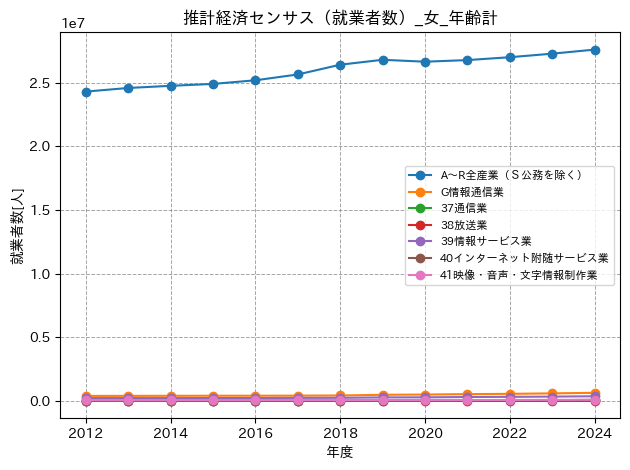

In [36]:
data_name = 'economic_census_employments_estimate'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_code_list = [int(code) for code in data_dict[f'{data_name}_df']['industry_code'].unique()]
    for industry_code in industry_code_list:
        # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
        industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

        df_extract = data_dict[f'{data_name}_df'].copy()
        df_extract = df_extract[df_extract['sex_code'] == sex_code]
        df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
        df_extract = df_extract[df_extract['industry_code'] == industry_code]
        df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'estimate_value']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = df_extract['estimate_value']

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='就業者数[人]', 
        path=fig_path
    )


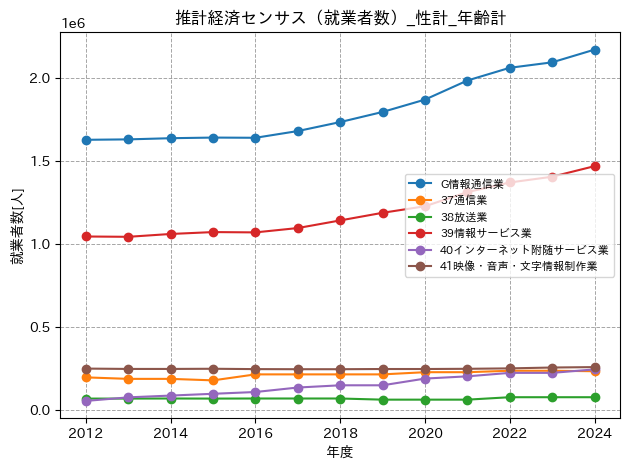

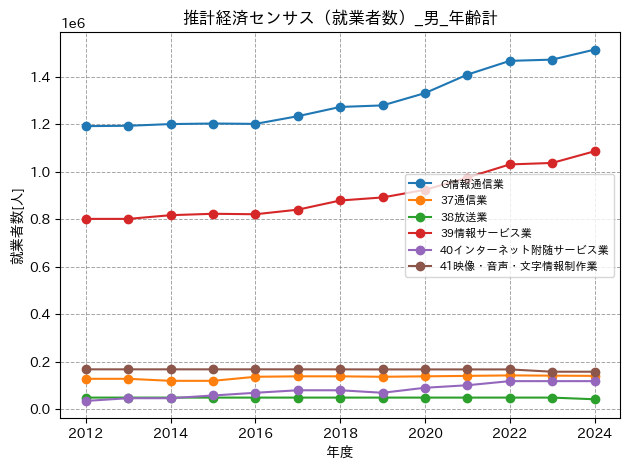

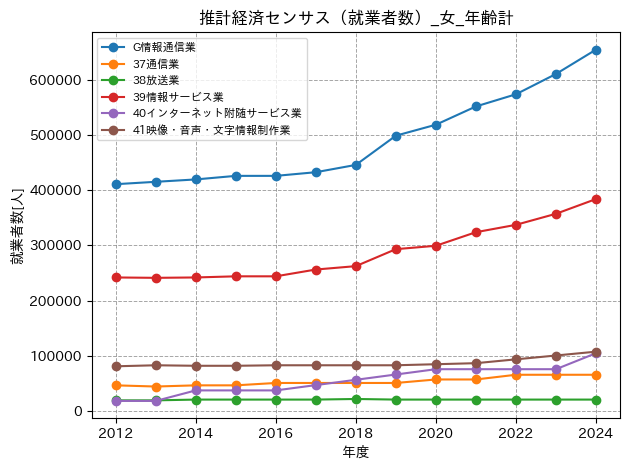

In [61]:
data_name = 'economic_census_employments_estimate'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_code_list = [int(code) for code in data_dict[f'{data_name}_df']['industry_code'].unique()]
    for industry_code in industry_code_list:
        if industry_code != 2:
            # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
            industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

            df_extract = data_dict[f'{data_name}_df'].copy()
            df_extract = df_extract[df_extract['sex_code'] == sex_code]
            df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
            df_extract = df_extract[df_extract['industry_code'] == industry_code]
            df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'estimate_value']]
            x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
            y_dict[f'{industry}'] = df_extract['estimate_value']

    # ファイル命名用に全産業の正式名称取得
    industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', 2, 'job_name_2012')
    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}_{industry}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='就業者数[人]', 
        path=fig_path
    )


### 推計構成比

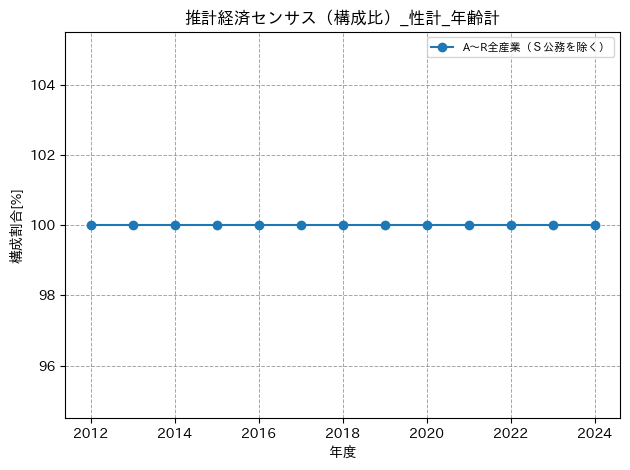

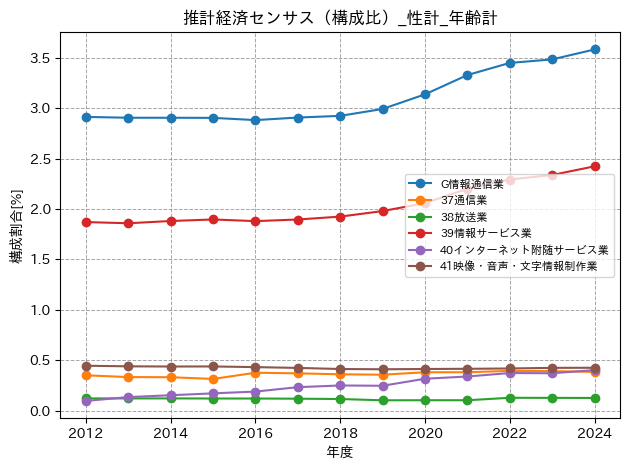

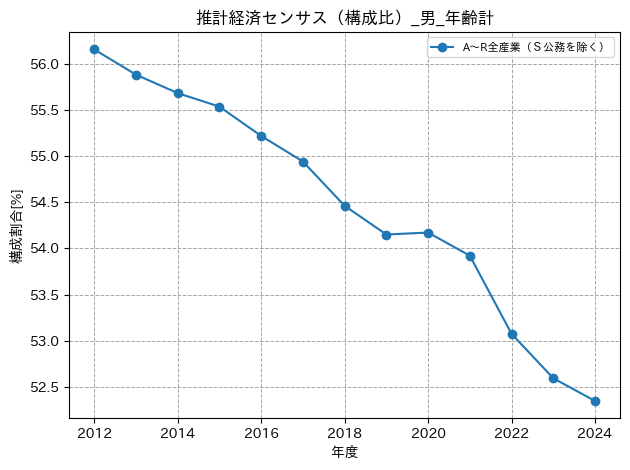

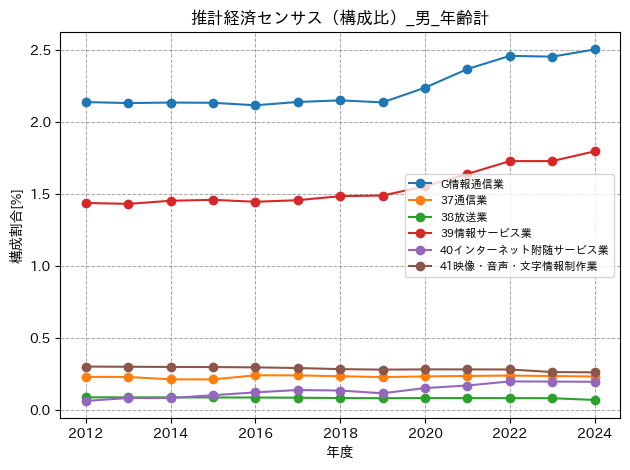

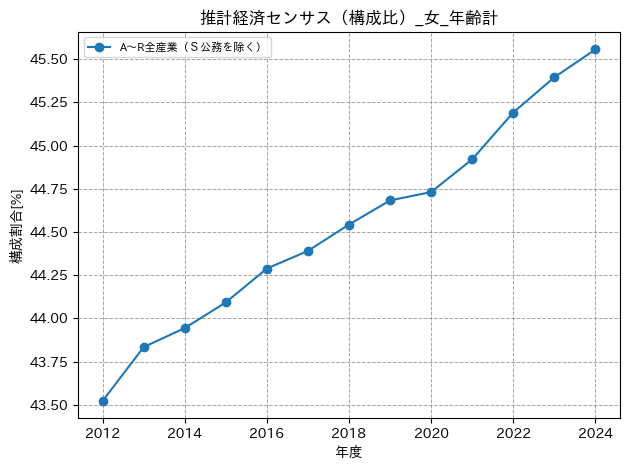

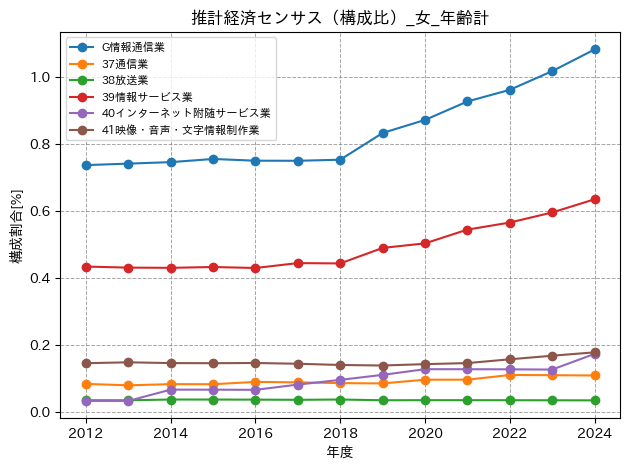

In [37]:
data_name = 'economic_census_employments_estimate_composition_rate'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}
    x_dict_2 = {}
    y_dict_2 = {}

    industry_code_list = [int(code) for code in data_dict[f'{data_name}_df']['industry_code'].unique()]
    for industry_code in industry_code_list:
        # 全産業とそれ以外では構成比が桁違いなので、分けて出力する
        if industry_code == 2:
            # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
            industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

            df_extract = data_dict[f'{data_name}_df'].copy()
            df_extract = df_extract[df_extract['sex_code'] == sex_code]
            df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
            df_extract = df_extract[df_extract['industry_code'] == industry_code]
            df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'composition_rate']]
            x_dict_2[f'{industry}'] = [int(year) for year in df_extract['year']]
            y_dict_2[f'{industry}'] = [composition_rate*100 for composition_rate in df_extract['composition_rate']]
        else:
            # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
            industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

            df_extract = data_dict[f'{data_name}_df'].copy()
            df_extract = df_extract[df_extract['sex_code'] == sex_code]
            df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
            df_extract = df_extract[df_extract['industry_code'] == industry_code]
            df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'composition_rate']]
            x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
            y_dict[f'{industry}'] = [composition_rate*100 for composition_rate in df_extract['composition_rate']]

    # ファイル命名用に全産業の正式名称取得
    industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', 2, 'job_name_2012')
    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}_{industry}.png')
    Make_line_plot(
        x_dict_2, 
        y_dict_2, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='構成割合[%]', 
        path=fig_path
    )
    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}_{industry}以外.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='構成割合[%]', 
        path=fig_path
    )


### 推計経年変化率

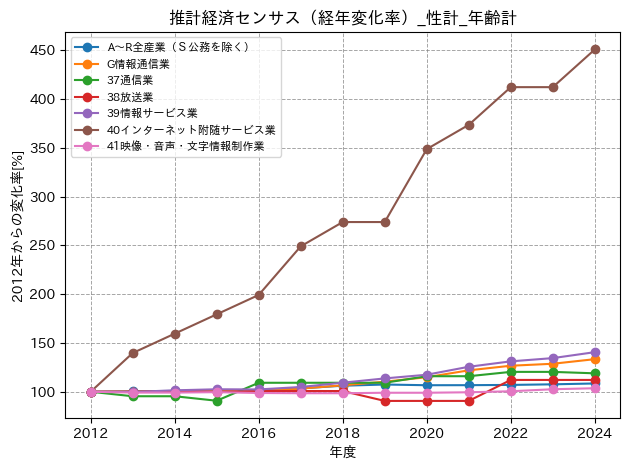

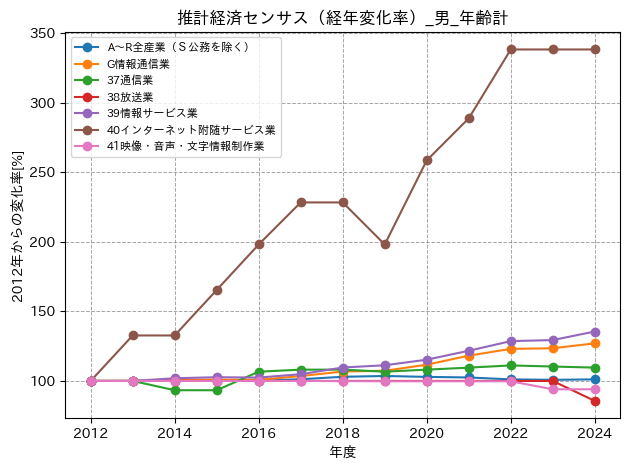

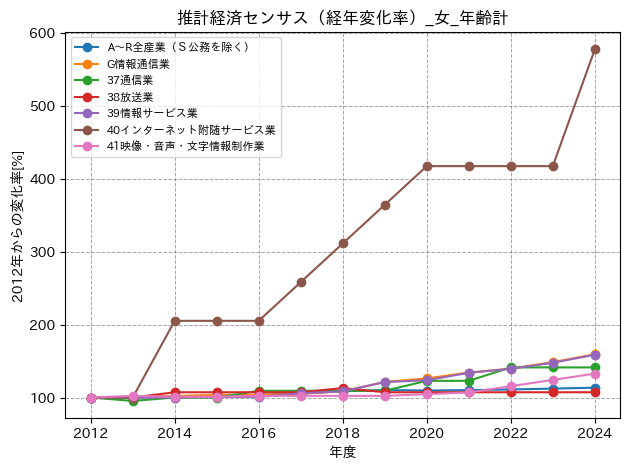

In [38]:
data_name = 'economic_census_employments_estimate_chronologica_rate'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_code_list = [int(code) for code in data_dict[f'{data_name}_df']['industry_code'].unique()]
    for industry_code in industry_code_list:
        # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
        industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

        df_extract = data_dict[f'{data_name}_df'].copy()
        df_extract = df_extract[df_extract['sex_code'] == sex_code]
        df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
        df_extract = df_extract[df_extract['industry_code'] == industry_code]
        df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'chronologica_rate']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = [chronologica_rate*100 for chronologica_rate in df_extract['chronologica_rate']]

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='2012年からの変化率[%]', 
        path=fig_path
    )


#### 「40インターネット附随サービス業」除外

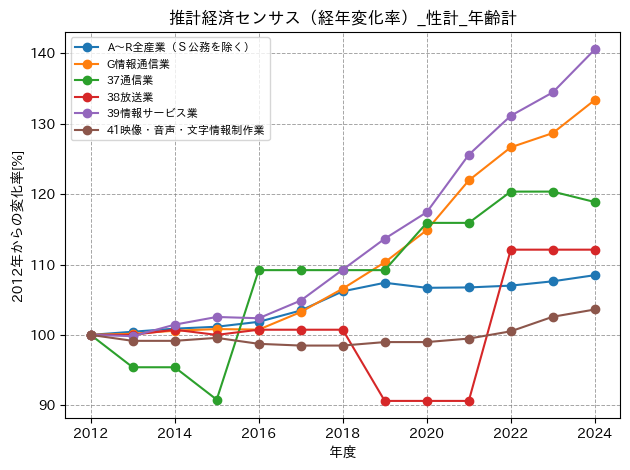

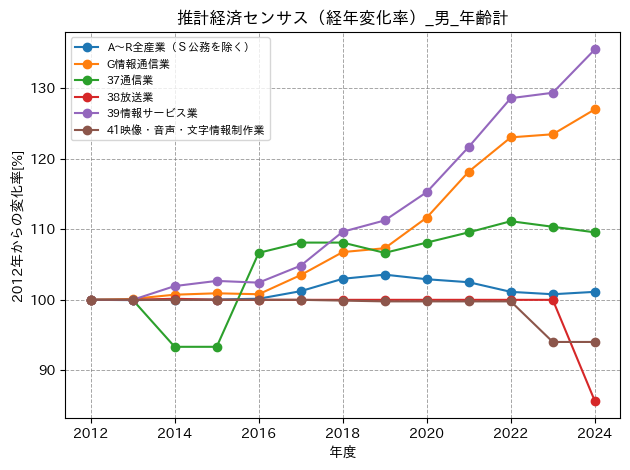

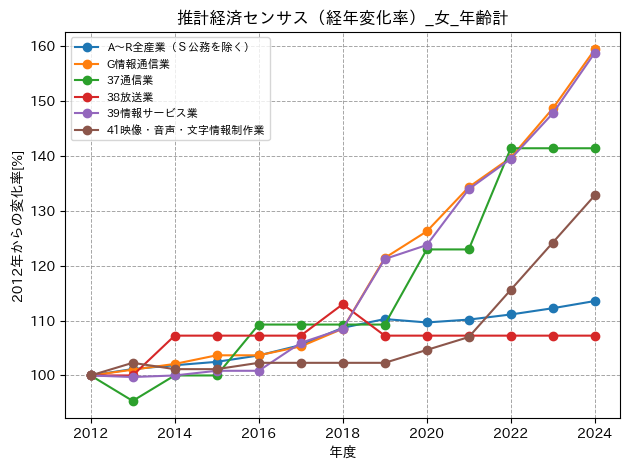

In [39]:
data_name = 'economic_census_employments_estimate_chronologica_rate'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_code_list = [int(code) for code in data_dict[f'{data_name}_df']['industry_code'].unique()]
    for industry_code in industry_code_list:
        # コード値とコード内容の対応表は推計モデル用に作成しなおしていないので、data_nameではなく直接テーブル名を指定
        industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

        if industry != '40インターネット附随サービス業':
            df_extract = data_dict[f'{data_name}_df'].copy()
            df_extract = df_extract[df_extract['sex_code'] == sex_code]
            df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
            df_extract = df_extract[df_extract['industry_code'] == industry_code]
            df_extract = df_extract[['sex_code', 'prefecture_code', 'year', 'industry_code', 'chronologica_rate']]
            x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
            y_dict[f'{industry}'] = [chronologica_rate*100 for chronologica_rate in df_extract['chronologica_rate']]

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}_40インターネット附随サービス業以外.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='2012年からの変化率[%]', 
        path=fig_path
    )


# 推計モデルの結果に基づいた都道府県の分類

分類にはk-means法を用いる

## 推計モデルの結果を横持ちに変換

主キーにはprefecture_codeのみを残して、industry_code, sex_code, yearの情報を横持ちに変換

In [40]:

data_dict['estimate_horizontal_df'] = data_dict['economic_census_employments_estimate_df'].query('prefecture_code>0')
data_dict['estimate_horizontal_df'] = Vertical_to_horizontal_df(df=data_dict['estimate_horizontal_df'], 
                                               primary_key_list=['prefecture_code'], 
                                               move_column_list=['industry_code', 'sex_code', 'year'], 
                                               use_column_list=['estimate_value']
                                               )

In [41]:
name_dict['estimate_horizontal'] = '横持推計経済センサス（就業者数）'
data_dict['estimate_horizontal_columns'], data_dict['estimate_horizontal_number_of_rows'] = Check_df(data_dict['estimate_horizontal_df'])

データフレームの冒頭5行を表示
   prefecture_code  estimate_value_industry2_sex0_year2012  \
0                1                               2159641.0   
1                2                                503372.0   
2                3                                509979.0   
3                4                                955780.0   
4                5                                418749.0   

   estimate_value_industry2_sex0_year2013  \
0                            2.161100e+06   
1                            5.041446e+05   
2                            5.139110e+05   
3                            9.698143e+05   
4                            4.198792e+05   

   estimate_value_industry2_sex0_year2014  \
0                            2.162440e+06   
1                            5.052789e+05   
2                            5.156849e+05   
3                            9.819646e+05   
4                            4.210612e+05   

   estimate_value_industry2_sex0_year2015  \
0                       

## 横持ちテーブルに主成分分析を実施してカラム数削減

In [42]:
data_dict['estimate_horizontal_pca_df'], explained_variance_ratio, cumulative_variance_ratio = \
Principal_component_analysis_df(data_dict['estimate_horizontal_df'], 
                                n_components=2,
                                column_list=None, 
                                primary_key_column_list=['prefecture_code']
                                )

In [65]:
explained_variance_ratio

[0.9107076617729704, 0.07114871887159721]

In [43]:
name_dict['estimate_horizontal_pca'] = '推計経済センサス（就業者数）の主成分分析'
data_dict['estimate_horizontal_pca_columns'], data_dict['estimate_horizontal_pca_number_of_rows'] = Check_df(data_dict['estimate_horizontal_pca_df'])

データフレームの冒頭5行を表示
   prefecture_code       PC1       PC2
0                1  3.963410  4.201628
1                2 -4.710883 -2.073331
2                3 -4.818108 -2.245321
3                4 -1.052135  0.654048
4                5 -5.479434 -2.611997
データフレームのカラム一覧、カラム数、列数を表示
カラム一覧: ['prefecture_code', 'PC1', 'PC2']
カラム数: 3
行数: 47
データフレームの基本情報を表示
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   prefecture_code  47 non-null     int64  
 1   PC1              47 non-null     float64
 2   PC2              47 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.2 KB
None
データフレームの統計量を表示
       prefecture_code           PC1           PC2
count        47.000000  4.700000e+01  4.700000e+01
mean         24.000000  8.125888e-16 -3.543265e-16
std          13.711309  1.593826e+01  4.454868e+00
min           1.000000 -6.077694e+00 -9.672752e+00
25%    

### 主成分分析の結果可視化

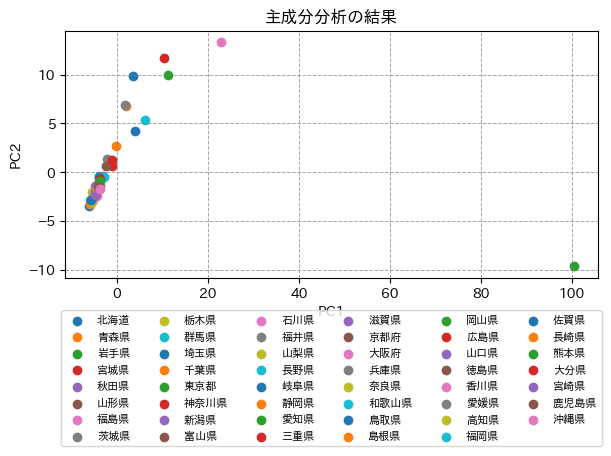

In [44]:
x_dict = {}
y_dict = {}
primary_key_list = data_dict['estimate_horizontal_pca_df']['prefecture_code'].unique()
for primary_key in primary_key_list:
    prefecture = Code_to_content(data_dict['prefecture_metadata_codes_df'], 'prefecture_code', primary_key, 'prefecture_name')
    x_dict[f'{prefecture}'] = float(data_dict['estimate_horizontal_pca_df'].query(f'prefecture_code=={primary_key}')['PC1'][:1].values[0])
    y_dict[f'{prefecture}'] = float(data_dict['estimate_horizontal_pca_df'].query(f'prefecture_code=={primary_key}')['PC2'][:1].values[0])

fig_path = os.path.join(python_root, 'output', 'img', f'scatter_plot_{name_dict['estimate_horizontal_pca']}.png')
Make_scatter_plot(
    x_dict, 
    y_dict, 
    x_integer=False, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title='主成分分析の結果', 
    xlabel='PC1', 
    ylabel='PC2', 
    legend_bottom=True, 
    ncol=6,
    path=fig_path
)


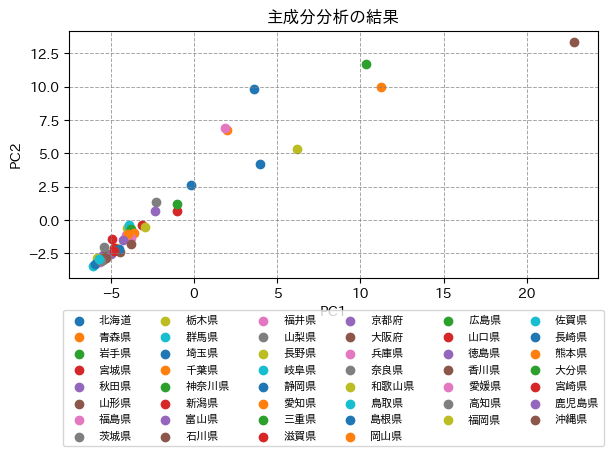

In [45]:
x_dict = {}
y_dict = {}
primary_key_list = data_dict['estimate_horizontal_pca_df']['prefecture_code'].unique()
for primary_key in primary_key_list:
    prefecture = Code_to_content(data_dict['prefecture_metadata_codes_df'], 'prefecture_code', primary_key, 'prefecture_name')
    if prefecture != '東京都':
        x_dict[f'{prefecture}'] = float(data_dict['estimate_horizontal_pca_df'].query(f'prefecture_code=={primary_key}')['PC1'][:1].values[0])
        y_dict[f'{prefecture}'] = float(data_dict['estimate_horizontal_pca_df'].query(f'prefecture_code=={primary_key}')['PC2'][:1].values[0])

fig_path = os.path.join(python_root, 'output', 'img', f'scatter_plot_{name_dict['estimate_horizontal_pca']}_東京都以外.png')
Make_scatter_plot(
    x_dict, 
    y_dict, 
    x_integer=False, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title='主成分分析の結果', 
    xlabel='PC1', 
    ylabel='PC2', 
    legend_bottom=True, 
    ncol=6,
    path=fig_path
)


## K-meansクラスタリング実施

東京都（コード値13）は明らかに外れているので、最初から除外

In [46]:
name_dict['estimate_horizontal_clustering'] = '推計経済センサス（就業者数）クラスタリング'

### K=3

In [47]:
n_clusters=3

In [48]:
df_cluster = data_dict['estimate_horizontal_pca_df'][['prefecture_code', 'PC1', 'PC2']].query('prefecture_code!=13')
data_dict['estimate_horizontal_clustering_df'] = K_means_2D(df_cluster, primary_key_list=['prefecture_code'], n_clusters=n_clusters, n_init=10)

#### 可視化

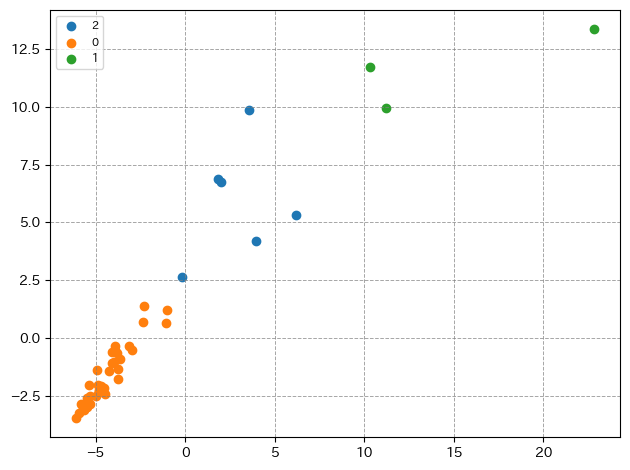

In [49]:
x_dict = {}
y_dict = {}
primary_key_list = data_dict['estimate_horizontal_clustering_df']['cluster'].unique()

for primary_key in primary_key_list:
    if prefecture != '東京都':
        x_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC1']
        y_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC2']

fig_path = os.path.join(python_root, 'output', 'img', f'scatter_plot_{name_dict['estimate_horizontal_clustering']}_東京都以外_K={n_clusters}.png')
Make_scatter_plot(
    x_dict, 
    y_dict, 
    x_integer=False, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title='', 
    xlabel='', 
    ylabel='', 
    legend_bottom=False, 
    ncol=3, 
    path=None)

### K=4

In [50]:
n_clusters=4

In [51]:
df_cluster = data_dict['estimate_horizontal_pca_df'][['prefecture_code', 'PC1', 'PC2']].query('prefecture_code!=13')
data_dict['estimate_horizontal_clustering_df'] = K_means_2D(df_cluster, primary_key_list=['prefecture_code'], n_clusters=n_clusters, n_init=10)

#### 可視化

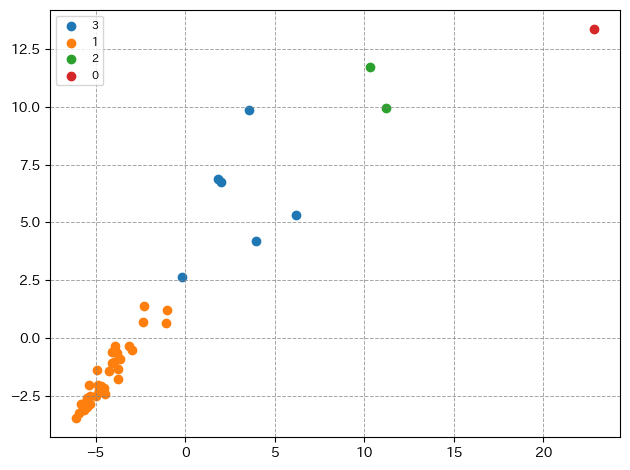

In [52]:
x_dict = {}
y_dict = {}
primary_key_list = data_dict['estimate_horizontal_clustering_df']['cluster'].unique()

for primary_key in primary_key_list:
    if prefecture != '東京都':
        x_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC1']
        y_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC2']

fig_path = os.path.join(python_root, 'output', 'img', f'scatter_plot_{name_dict['estimate_horizontal_clustering']}_東京都以外_K={n_clusters}.png')
Make_scatter_plot(
    x_dict, 
    y_dict, 
    x_integer=False, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title='', 
    xlabel='', 
    ylabel='', 
    legend_bottom=False, 
    ncol=3, 
    path=fig_path)

### K=5

#### クラスタリング実行

In [53]:
n_clusters=5

In [54]:
df_cluster = data_dict['estimate_horizontal_pca_df'][['prefecture_code', 'PC1', 'PC2']].query('prefecture_code!=13')
data_dict['estimate_horizontal_clustering_df'] = K_means_2D(df_cluster, primary_key_list=['prefecture_code'], n_clusters=n_clusters, n_init=10)

#### 可視化

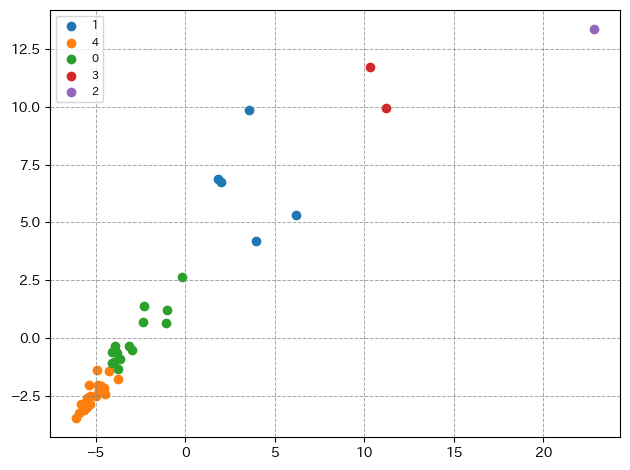

In [55]:
x_dict = {}
y_dict = {}
primary_key_list = data_dict['estimate_horizontal_clustering_df']['cluster'].unique()

for primary_key in primary_key_list:
    if prefecture != '東京都':
        x_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC1']
        y_dict[f'{primary_key}'] = data_dict['estimate_horizontal_clustering_df'].query(f'cluster=={primary_key}')['PC2']

fig_path = os.path.join(python_root, 'output', 'img', f'scatter_plot_{name_dict['estimate_horizontal_clustering']}_東京都以外_K={n_clusters}.png')
Make_scatter_plot(
    x_dict, 
    y_dict, 
    x_integer=False, 
    y_integer=False, 
    x_lim=None, 
    y_lim=None, 
    title='', 
    xlabel='', 
    ylabel='', 
    legend_bottom=False, 
    ncol=3, 
    path=fig_path)

## クラスタリング結果を推計モデル結果のテーブルに結合

結合元の推計モデル結果は横持ち変換後のテーブルとする（カラム数の関係でクラスタリング結果に推計モデルの結果を結合する）。

### テーブル名指定

In [56]:
name_dict['estimate_horizontal_clustering_5'] = '推計経済センサス（就業者数）クラスタリング(K=5)'

### 結合処理

In [57]:
# prefecture_codeから都道府県名を取得してデータフレームに追加
data_dict['estimate_horizontal_df']['prefecture_name'] = ''
for prefecture_code in data_dict['estimate_horizontal_df']['prefecture_code'].unique():
    prefecture_name = Code_to_content(data_dict['prefecture_metadata_codes_df'], 'prefecture_code', prefecture_code, 'prefecture_name')
    index_num = data_dict['estimate_horizontal_df'].query(f'prefecture_code=={prefecture_code}').index[0]
    column_num = data_dict['estimate_horizontal_df'].columns.get_loc('prefecture_name')
    data_dict['estimate_horizontal_df'].iat[index_num, column_num] = prefecture_name

# データフレームの結合
data_dict['estimate_horizontal_clustering_5_df'] = pd.merge(data_dict['estimate_horizontal_df'], 
                                                            data_dict['estimate_horizontal_clustering_df'], 
                                                            on=['prefecture_code'],
                                                            how='left')



C:\Users\hanju\AppData\Local\Temp\ipykernel_37756\3031133823.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_dict['estimate_horizontal_df']['prefecture_name'] = ''


In [58]:
# クラスタリング時に東京都を除外したので、PC1とPC2をestimate_horizontal_pca_dfテーブルから取得して補完。clusterは99とする。
index_num = data_dict['estimate_horizontal_clustering_5_df'].query('prefecture_code==13').index[0]
column_num_PC1 = data_dict['estimate_horizontal_clustering_5_df'].columns.get_loc('PC1')
column_num_PC2 = data_dict['estimate_horizontal_clustering_5_df'].columns.get_loc('PC2')
column_num_cluster = data_dict['estimate_horizontal_clustering_5_df'].columns.get_loc('cluster')
data_dict['estimate_horizontal_clustering_5_df'].iat[index_num, column_num_PC1] = \
    float(data_dict['estimate_horizontal_pca_df'].query('prefecture_code==13')['PC1'][:1].values[0])
data_dict['estimate_horizontal_clustering_5_df'].iat[index_num, column_num_PC2] = \
    float(data_dict['estimate_horizontal_pca_df'].query('prefecture_code==13')['PC2'][:1].values[0])
data_dict['estimate_horizontal_clustering_5_df'].iat[index_num, column_num_cluster] = 99
# カラム順を入れ替え
estimate_column_list = [column for column in data_dict['estimate_horizontal_clustering_5_df'].columns if 'estimate' in column]
data_dict['estimate_horizontal_clustering_5_df'] = \
    data_dict['estimate_horizontal_clustering_5_df'][['prefecture_code', 'prefecture_name', 'cluster', 'PC1', 'PC2']+estimate_column_list]
# clusterカラムを整数に変換してカテゴリ型に変更
data_dict['estimate_horizontal_clustering_5_df']['cluster'] = data_dict['estimate_horizontal_clustering_5_df']['cluster'].astype("int32")
data_dict['estimate_horizontal_clustering_5_df']['cluster'] = data_dict['estimate_horizontal_clustering_5_df']['cluster'].astype("category")


### 出力

In [59]:
name_dict['estimate_horizontal_clustering_5']

'推計経済センサス（就業者数）クラスタリング(K=5)'

In [60]:
file_path = os.path.join(python_root, 'output', 'csv', f'scatter_plot_{name_dict['estimate_horizontal_clustering_5']}.csv')
Write_csv_from_df(data_dict['estimate_horizontal_clustering_5_df'], 
                  file_path=file_path, 
                  encoding="utf-8-sig", 
                  index=False)